# Exp8.0.1 — Frozen L1/L2 Fusion Probe

This notebook is aggregation-only. It reads finalized Exp8.0.1 CSV/JSON artifacts and does not retrain the SNN or refit probes.

Primary question: does the frozen Exp8.0 `234x234` backbone contain complementary information across L1 and L2, especially `L1 whole + L2 Fixed250`?

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd()
while repo.name != 'writingRing' and repo.parent != repo:
    repo = repo.parent
base = repo / 'notebooks' / 'artifacts' / 'experiment_8_0_1_l1_l2_fusion_probe' / 'l1_l2_fusion_probe_v1'
manifest = json.loads((base / 'manifest.json').read_text())
probe_runs = pd.read_csv(base / 'probe_runs.csv')
probe_summary = pd.read_csv(base / 'probe_summary.csv')
fusion_runs = pd.read_csv(base / 'fusion_gain_runs.csv')
fusion_summary = pd.read_csv(base / 'fusion_gain_summary.csv')
overlap_runs = pd.read_csv(base / 'correctness_overlap_runs.csv')
overlap_summary = pd.read_csv(base / 'correctness_overlap_summary.csv')
coef_runs = pd.read_csv(base / 'coef_block_runs.csv')
coef_summary = pd.read_csv(base / 'coef_block_summary.csv')
manifest

{'backbone_training': 'none; reuse and freeze Exp8.0 234x234 checkpoints',
 'experiment_id': 'experiment_8_0_1_l1_l2_fusion_probe',
 'feature_specs': {'l1_fixed250': [['l1', 'fixed250']],
  'l1_l2_fixed250': [['l1', 'fixed250'], ['l2', 'fixed250']],
  'l1_l2_whole': [['l1', 'whole_count'], ['l2', 'whole_count']],
  'l1_whole': [['l1', 'whole_count']],
  'l1fixed250_l2whole': [['l1', 'fixed250'], ['l2', 'whole_count']],
  'l1whole_l2fixed250': [['l1', 'whole_count'], ['l2', 'fixed250']],
  'l2_fixed250': [['l2', 'fixed250']],
  'l2_whole': [['l2', 'whole_count']]},
 'parallel_runs': 3,
 'primary_question': 'Do frozen L1 and L2 spike representations carry complementary whole-count and/or ordered Fixed250 information?',
 'probe_protocol': 'train-only StandardScaler + validation-selected LogisticRegression C',
 'protocol_version': 'l1_l2_fusion_probe_v1',
 'seeds': [11, 23, 37],
 'source_architecture': '234x234',
 'source_experiment_id': 'experiment_8_0_local_backbone_tau_sweep',
 'source_

## Main frozen-probe comparison

The important comparison is test BA and its paired-seed behavior, not training fit. The train-test gap is shown explicitly because Fixed250 fusion is high-dimensional.

In [2]:
cols = [
    'feature', 'feature_dim_mean',
    'train_ba_mean', 'val_ba_mean', 'test_ba_mean', 'test_ba_std',
    'train_test_gap_mean', 'probe_C_mean',
]
display(probe_summary[cols].sort_values('test_ba_mean', ascending=False))

,feature,feature_dim_mean,train_ba_mean,val_ba_mean,test_ba_mean,test_ba_std,train_test_gap_mean,probe_C_mean
2,l1_l2_whole,256.0,0.923514,0.558961,0.602787,0.008824,0.320726,0.010
4,l1fixed250_l2whole,2176.0,0.984715,0.579383,0.596961,0.032201,0.387754,0.370
6,l2_fixed250,2048.0,0.990478,0.591410,0.589402,0.020599,0.401076,0.070
5,l1whole_l2fixed250,2176.0,0.990478,0.582307,0.588861,0.013910,0.401617,0.070
1,l1_l2_fixed250,4096.0,0.971478,0.585033,0.586492,0.021215,0.384986,0.337
3,l1_whole,128.0,0.928250,0.527944,0.586489,0.034025,0.341761,0.700
7,l2_whole,128.0,0.946805,0.557890,0.573312,0.023171,0.373493,3.340
0,l1_fixed250,2048.0,0.990336,0.540610,0.540128,0.030321,0.450208,0.700


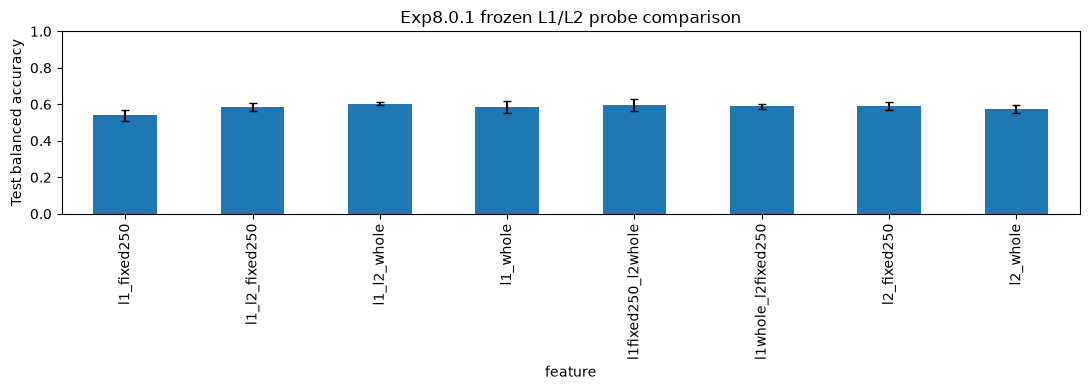

In [3]:
plot = probe_summary.set_index('feature')
ax = plot['test_ba_mean'].plot.bar(yerr=plot['test_ba_std'], capsize=3, figsize=(11, 4))
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Exp8.0.1 frozen L1/L2 probe comparison')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Fusion gains

Positive values mean the fused feature beats the relevant best single-layer component on the same seed.

In [4]:
display(fusion_runs)
display(fusion_summary.sort_values('mean', ascending=False))

,seed,fixed250_fusion_gain_over_best_single,l1whole_l2fixed250_gain_over_best_component,l1whole_l2fixed250_gain_over_l2fixed250,reverse_mixed_gain_over_best_component,whole_fusion_gain_over_best_single
0,11,0.013528,0.005952,0.005952,0.031597,0.019481
1,23,-0.003637,-0.007576,-0.007576,0.011844,0.037388
2,37,-0.018622,-0.040931,0.000000,0.027507,-0.013009


,metric,mean,std
3,reverse_mixed_gain_over_best_component,0.023649,0.010426
4,whole_fusion_gain_over_best_single,0.014620,0.025548
2,l1whole_l2fixed250_gain_over_l2fixed250,-0.000541,0.006780
0,fixed250_fusion_gain_over_best_single,-0.002910,0.016087
1,l1whole_l2fixed250_gain_over_best_component,-0.014185,0.024130


## L1/L2 correctness overlap

`l1_only_correct` and `l2_only_correct` quantify error complementarity directly. `oracle_union_accuracy` is diagnostic only; it is not a deployable classifier.

In [5]:
test_overlap = overlap_summary[overlap_summary['split'] == 'test'].copy()
display(test_overlap)

,aggregation,split,both_correct_mean,both_correct_std,l1_only_correct_mean,l1_only_correct_std,l2_only_correct_mean,l2_only_correct_std,both_wrong_mean,both_wrong_std,prediction_disagreement_mean,prediction_disagreement_std,oracle_union_accuracy_mean,oracle_union_accuracy_std
0,fixed250,test,0.481735,0.007909,0.070776,0.027681,0.123288,0.029855,0.324201,0.028516,0.335616,0.027397,0.675799,0.028516
3,whole,test,0.486301,0.036243,0.107306,0.010463,0.098174,0.024054,0.308219,0.018122,0.328767,0.029855,0.691781,0.018122


## Fusion coefficient blocks

Features are standardized before the probe. `coef_rms` is therefore useful for checking whether a fused probe uses both L1 and L2 rather than effectively ignoring one block.

In [6]:
multi = coef_summary[coef_summary['feature'].isin([
    'l1_l2_whole', 'l1_l2_fixed250',
    'l1whole_l2fixed250', 'l1fixed250_l2whole'
])].copy()
display(multi[[
    'feature', 'block_index', 'layer', 'aggregation',
    'coef_rms_mean', 'coef_rms_std',
    'coef_norm_fraction_mean', 'coef_norm_fraction_std',
]])

,feature,block_index,layer,aggregation,coef_rms_mean,coef_rms_std,coef_norm_fraction_mean,coef_norm_fraction_std
1,l1_l2_fixed250,0,l1,fixed250,0.006533,0.006239,0.339842,0.014051
2,l1_l2_fixed250,1,l2,fixed250,0.012216,0.011008,0.660158,0.014051
3,l1_l2_whole,0,l1,whole_count,0.016982,0.000274,0.272443,0.002847
4,l1_l2_whole,1,l2,whole_count,0.045349,0.000345,0.727557,0.002847
6,l1fixed250_l2whole,0,l1,fixed250,0.018557,0.012326,0.510368,0.032388
7,l1fixed250_l2whole,1,l2,whole_count,0.067612,0.036602,0.489632,0.032388
8,l1whole_l2fixed250,0,l1,whole_count,0.011895,0.003838,0.166454,0.003881
9,l1whole_l2fixed250,1,l2,fixed250,0.014889,0.004770,0.833546,0.003881


## Interpretation checklist

- If `l1_l2_whole` or `l1_l2_fixed250` consistently beats the stronger corresponding single layer, L1 and L2 contain complementary information at that aggregation scale.
- If `l1whole_l2fixed250` is strongest and both coefficient blocks remain active, the data support an explicit multi-level path preserving L1 aggregate evidence while retaining L2 phase-aware evidence.
- If fusion improves train BA but not validation/test BA, prioritize invariance/augmentation rather than a larger skip architecture.
- If L1-only-correct is near zero, there is little evidence that a skip path is necessary even if raw dimensions increase.